# Q-1 Decision Tree for Heart Disease Prediction

This notebook implements Parts A–E of the assignment using the **Heart Disease dataset provided in `heart_v2.pdf`**.

**Columns:** `age`, `sex`, `BP`, `cholestrol`, `heart disease`  
**Target:** `heart disease` (0 = without disease, 1 = with disease)

> Note: the source PDF does not define which real-world sex category is represented by 0 or 1, so the analysis keeps `sex` as an encoded numeric feature without assigning labels.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, balanced_accuracy_score
)

## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv("heart_disease.csv")

print("Shape = ", df.shape)
display(df.head())
display(df.info())
print("\nMissing values = ")
display(df.isna().sum())
print("\nClass distribution = ")
display(df["heart disease"].value_counts().sort_index())

Shape =  (270, 5)


,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    int64
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: int64(5)
memory usage: 10.7 KB


None


Missing values = 


age              0
sex              0
BP               0
cholestrol       0
heart disease    0
dtype: int64


Class distribution = 


heart disease
0    150
1    120
Name: count, dtype: int64

## Part A — Basic Implementation

We split the data into 80% training and 20% testing data. `stratify=y` keeps the disease/no-disease proportion similar in both sets. A basic Decision Tree uses the default Gini criterion.

In [3]:
X = df.drop(columns=["heart disease"])
y = df["heart disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print(f"Training accuracy = {accuracy_score(y_train, dt.predict(X_train)):.4f}")
print(f"Testing accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Tree depth        = {dt.get_depth()}")
print(f"Number of leaves  = {dt.get_n_leaves()}")

Training accuracy = 1.0000
Testing accuracy  = 0.6667
Tree depth        = 11
Number of leaves  = 60


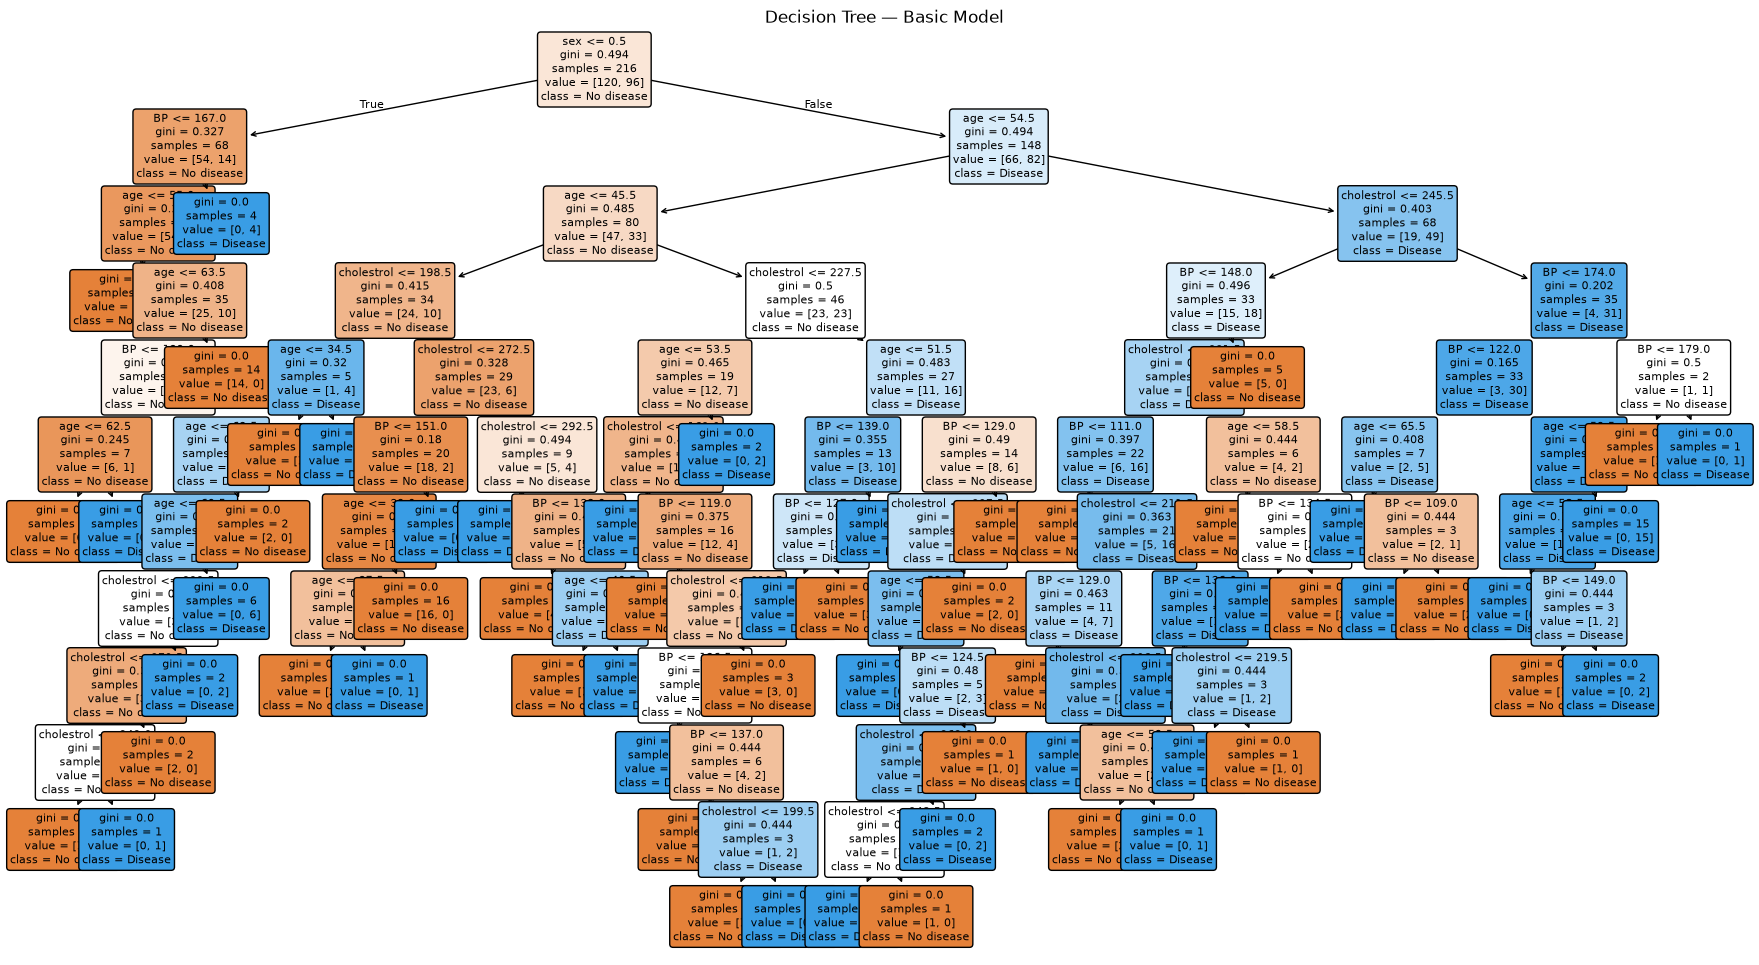

In [4]:
# Decision-tree visualization
plt.figure(figsize=(22, 12))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree — Basic Model")
plt.show()

### Interpretation of the first two splits

For this train/test split and `random_state=42`, the root split is:

- **`sex <= 0.50`** → separates the two encoded sex groups.
- On the `sex <= 0.50` branch, the next split is **`BP <= 167`**.
- On the `sex > 0.50` branch, the next split is **`age <= 54.5`**.

The tree chooses these thresholds because they reduce impurity (Gini impurity) most effectively at those nodes. These rules are model-specific patterns, not medical diagnostic rules.

## Part B — Model Evaluation

Confusion Matrix = 
[[19 11]
 [ 7 17]]

Classification Report:
              precision    recall  f1-score   support

  No disease     0.7308    0.6333    0.6786        30
     Disease     0.6071    0.7083    0.6538        24

    accuracy                         0.6667        54
   macro avg     0.6690    0.6708    0.6662        54
weighted avg     0.6758    0.6667    0.6676        54



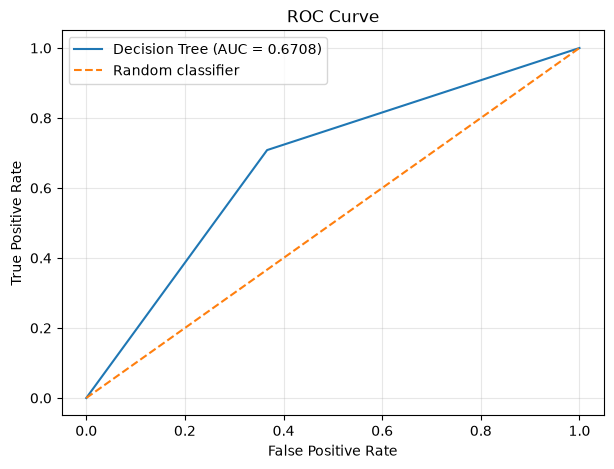

AUC: 0.6708


In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix = ")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No disease", "Disease"],
    digits=4
))

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {auc:.4f}")

## Part C — Hyperparameter Tuning

Changing tree complexity shows the underfitting/overfitting trade-off:
- small `max_depth` or large minimum-sample constraints → simpler tree, possible underfitting;
- very deep tree or tiny leaf/split constraints → more memorization, possible overfitting.

In [6]:
# Vary one hyperparameter at a time
rows = []

for d in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    rows.append(["max_depth", d, model.score(X_train, y_train), model.score(X_test, y_test)])

for s in [2, 5, 10, 15, 20, 30]:
    model = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    model.fit(X_train, y_train)
    rows.append(["min_samples_split", s, model.score(X_train, y_train), model.score(X_test, y_test)])

for l in [1, 2, 5, 10, 15, 20]:
    model = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    model.fit(X_train, y_train)
    rows.append(["min_samples_leaf", l, model.score(X_train, y_train), model.score(X_test, y_test)])

tuning_table = pd.DataFrame(
    rows,
    columns=["parameter", "value", "training_accuracy", "testing_accuracy"]
)

display(tuning_table.round(4))

,parameter,value,training_accuracy,testing_accuracy
0,max_depth,1.0,0.6296,0.5741
1,max_depth,2.0,0.7130,0.6296
2,max_depth,3.0,0.7130,0.6296
3,max_depth,4.0,0.7731,0.6481
4,max_depth,5.0,0.8287,0.6481
5,max_depth,6.0,0.8796,0.6296
6,max_depth,8.0,0.9537,0.6667
7,max_depth,10.0,0.9907,0.6481
8,max_depth,NaN,1.0000,0.6667
9,min_samples_split,2.0,1.0000,0.6667


In [7]:
# Automated GridSearchCV
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters = ", grid.best_params_)
print(f"Best 5-fold CV accuracy = {grid.best_score_:.4f}")

best_dt = grid.best_estimator_
best_pred = best_dt.predict(X_test)
best_prob = best_dt.predict_proba(X_test)[:, 1]

print(f"Best model training accuracy = {best_dt.score(X_train, y_train):.4f}")
print(f"Best model testing accuracy = {best_dt.score(X_test, y_test):.4f}")

Best parameters =  {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best 5-fold CV accuracy = 0.6943
Best model training accuracy = 0.7130
Best model testing accuracy = 0.6296


### Overfitting vs underfitting conclusion

The unrestricted basic tree gets **100% training accuracy** but only about **66.7% test accuracy**, a clear sign of overfitting.

A shallow tree such as `max_depth=1` has lower training and test accuracy, which is consistent with underfitting.

GridSearchCV selects a much simpler tree than the unrestricted model on this split. The cross-validation score is more reliable for tuning than simply choosing the model with the highest training accuracy.

## Part D — Error Analysis

In [8]:
# Find misclassified patients
mis_mask = y_pred != y_test.values

misclassified = X_test.loc[mis_mask].copy()

# Add actual and predicted labels
misclassified["actual"] = y_test.loc[misclassified.index]
misclassified["predicted"] = pd.Series(
    y_pred,
    index=X_test.index
).loc[misclassified.index]

print(f"Number of misclassified test patients: {len(misclassified)}")

display(misclassified.sort_index())

Number of misclassified test patients: 18


,age,sex,BP,cholestrol,actual,predicted
3,64,1,128,263,0,1
9,63,0,150,407,1,0
35,48,1,130,256,1,0
38,42,1,130,180,0,1
49,65,0,150,225,1,0
61,51,0,130,305,1,0
66,51,1,140,261,0,1
97,58,1,100,234,1,0
144,54,1,192,283,1,0
162,55,1,130,262,0,1


### Pattern noticed

For the basic tree, the errors are concentrated around **overlapping feature regions** rather than one perfectly separable group. The misclassified group has a slightly higher mean BP and almost the same mean age and cholesterol as the correctly classified group.

Examples from the test set include both:
- **false positives**: predicted disease when the actual class is 0;
- **false negatives**: predicted no disease when the actual class is 1.

This is expected because the dataset uses only four predictors, so many patients from the two classes have similar feature values.

## Part E — Class Imbalance Check

In [9]:
class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index() * 100

imbalance_table = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(2)
})
display(imbalance_table)

print(f"Balanced accuracy of basic tree = {balanced_accuracy_score(y_test, y_pred):.4f}")

,count,percentage
heart disease,,
0,150,55.56
1,120,44.44


Balanced accuracy of basic tree = 0.6708


### Conclusion

The dataset is **mildly imbalanced**: class 0 has 150 patients and class 1 has 120 patients. That is not an extreme imbalance, but accuracy alone should not be the only metric.

Therefore, report **balanced accuracy**, precision, recall, F1-score, and ROC-AUC together. SMOTE/undersampling can be tested as an additional experiment, but it is not strictly necessary for this level of class imbalance.

In [10]:
# Optional: SMOTE experiment (run only if imbalanced-learn is installed)
# pip install imbalanced-learn

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    smote_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    smote_dt.fit(X_train_smote, y_train_smote)
    smote_pred = smote_dt.predict(X_test)

    print("Before SMOTE:", y_train.value_counts().to_dict())
    print("After SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())
    print("SMOTE test accuracy :", accuracy_score(y_test, smote_pred))
    print("SMOTE balanced acc. :", balanced_accuracy_score(y_test, smote_pred))
except ImportError:
    print("imbalanced-learn is not installed. SMOTE section skipped.")

Before SMOTE: {0: 120, 1: 96}
After SMOTE : {0: 120, 1: 120}
SMOTE test accuracy : 0.6296296296296297
SMOTE balanced acc. : 0.6333333333333333
